# Logistic regression from scratch

La régression logistique permet de modéliser une probabilité pour une variable binaire \( y \in \{0, 1\} \).

## Logistic

$$
\hat{y} = \sigma(z) = \frac{1}{1 + e^{-z}}
$$

## Cost Function (log-loss)

$$
J(\theta) = -\frac{1}{m} \sum_{i=1}^{m} \left[ y^{(i)} \log(\hat{y}^{(i)}) + (1 - y^{(i)}) \log(1 - \hat{y}^{(i)}) \right]
$$

## Descent Gradient Optimization

$$
\theta := \theta - \alpha \cdot \nabla_\theta J(\theta)
$$



## Simple binary data generation

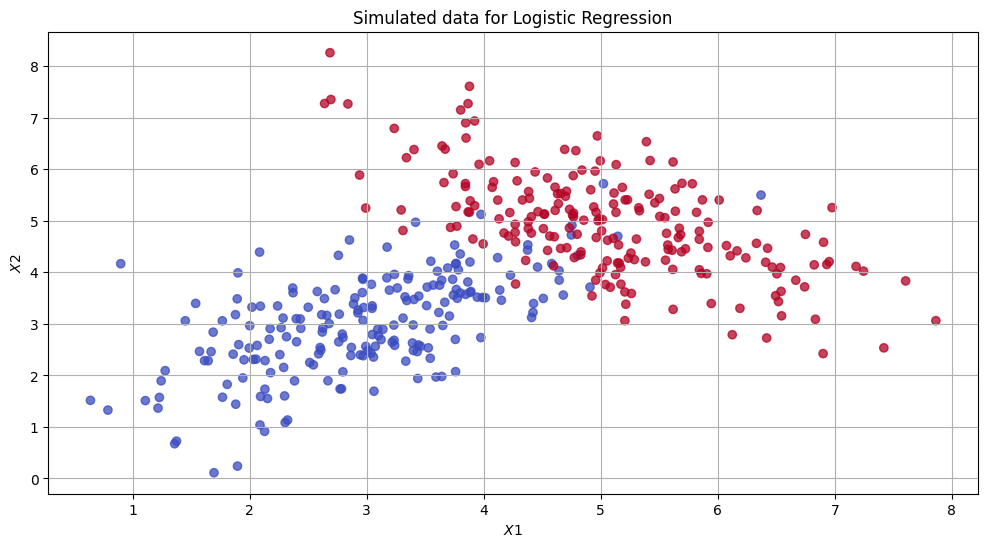

In [17]:
import numpy as np 
import matplotlib.pyplot as plt

np.random.seed(42)
n = 400

# Class 0
X0 = np.random.multivariate_normal(mean=[3, 3], cov=[[1, 0.64], [0.64, 1]], size = n//2)
y0 = np.zeros(n//2)

# Class 1
X1 = np.random.multivariate_normal(mean=[5, 5], cov=[[1, -0.64], [-0.64, 1]], size = n//2)
y1 = np.ones(n//2)

X = np.vstack([X0, X1])
y = np.concatenate([y0, y1])

plt.figure(figsize=(12,6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", alpha=0.75)
plt.title("Simulated data for Logistic Regression")
plt.xlabel("$X1$")
plt.ylabel("$X2$")
plt.grid(True)
plt.show()

## Sigmoid function and predictions

In [ ]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def predict_proba(X, theta):
    return sigmoid(X @ theta)

def predict(X, theta, threshold=0.5):
    return(predict_proba(X, theta) >= threshold).astype(int)

## Cost Function and Gradient calculation

In [19]:
def compute_cost(X, y, theta):
    s = predict_proba(X, theta)
    eps = 1e-15 # to avoid log(0)
    return - np.mean(y*np.log(s + eps) + (1 - y) * np.log(1 - s + eps))

def compute_gradient(X, y, theta):
    s = predict_proba(X, theta)
    return X.T @ (s-y) / len(y)

## Gradient Descent processing

In [20]:
def logistic_regression(X, y, lr=0.1, n_iter=10000):
    X = np.hstack([np.ones((X.shape[0], 1)), X]) # Bias column
    theta = np.zeros(X.shape[1])
    cost_history = []
    
    for _ in range(n_iter):
        cost = compute_cost(X, y, theta)
        gradient = compute_gradient(X, y, theta)
        theta = theta - lr * gradient 
        cost_history.append(cost)
        
    return theta, cost_history

## Training model

In [21]:
theta, costs = logistic_regression(X, y, lr=0.4, n_iter=15000)

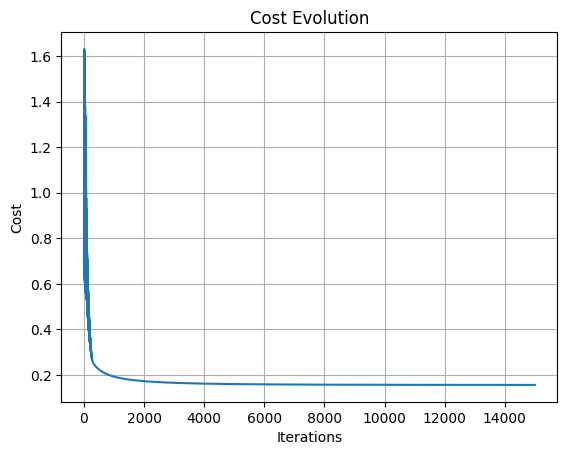

In [22]:
plt.plot(costs)
plt.title("Cost Evolution")
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.grid(True)
plt.show()

In [23]:
y

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1.

In [24]:
X_prepa = np.hstack([np.ones((X.shape[0], 1)), X])

(sigmoid(X_prepa @ theta) > 0.5).astype(int)

array([0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

## Decision Frontier

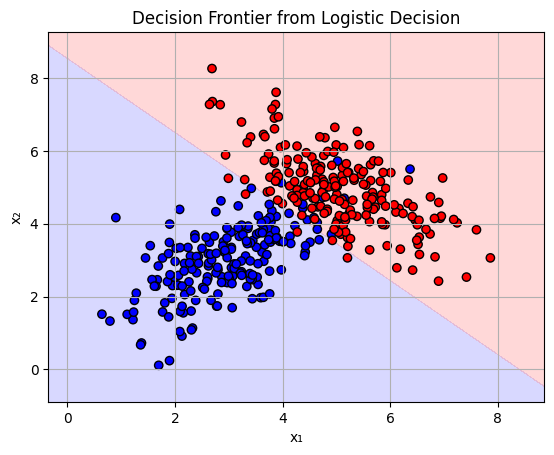

In [29]:
x1_grid, x2_grid = np.meshgrid(np.linspace(X[:,0].min()-1, X[:,0].max()+1, 100),
                               np.linspace(X[:,1].min()-1, X[:,1].max()+1, 100))

grid = np.c_[np.ones(x1_grid.size), x1_grid.ravel(), x2_grid.ravel()]

proba_grid = predict_proba(grid, theta).reshape(x1_grid.shape)

plt.Figure(figsize=(15,12))
plt.contourf(x1_grid, x2_grid, proba_grid, levels=[0, 0.5, 1], cmap="bwr", alpha=0.3)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="bwr", edgecolor='k')
plt.title("Decision Frontier from Logistic Decision")
plt.xlabel("x₁")
plt.ylabel("x₂")
plt.grid(True)
plt.show()

## Conclusion

- Logistic regression allows modeling the probability of a binary target variable.  
- It is based on the **sigmoid function** and a suitable **logistic cost function**.  
- It can be efficiently optimized using **gradient descent**, leveraging the analytical derivative of the cost.  
- The **decision boundary** separating the classes can be visualized at \( p = 0.5 \).
